# Analisis de conectividad en la red del CENTIC con BFS

Este notebook modela la red del CENTIC como un grafo no dirigido y aplica BFS para determinar si existe una ruta valida entre un dispositivo de origen y el servidor central bajo restricciones de seguridad, ancho de banda y latencia.

In [1]:
import random
from collections import deque
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Modelo del grafo

Sea $G=(V,E)$ un grafo no dirigido. Cada vertice representa un dispositivo de red o un equipo final. Cada arista representa una conexion fisica y tiene atributos $(s, b, l)$ donde $s$ es seguridad, $b$ es ancho de banda (Mbps) y $l$ es latencia (ms).

Una arista es valida si cumple: $s \ge s_{min}$, $b \ge b_{min}$ y $l \le l_{max}$. El problema se reduce a encontrar un camino en el subgrafo de aristas validas.

In [2]:
random.seed(42)

## Escenarios y umbrales

Se consideran tres escenarios de operacion:

- Normal: requisitos corporativos estandar sobre fibra.
- Alta seguridad: mayores exigencias para enlaces criticos.
- Congestion: tolera mayor latencia y menor ancho de banda.

In [3]:
SCENARIOS = {
    "normal": {"s_min": 3, "b_min": 100, "l_max": 30},
    "alta_seguridad": {"s_min": 4, "b_min": 200, "l_max": 20},
    "congestion": {"s_min": 3, "b_min": 50, "l_max": 50},
}

## Construccion del grafo

Se modelan 4 pisos, cada uno con 6 aulas (5 normales con 15 PCs y 1 aula grande con 30 PCs). Cada aula tiene un PC central y una camara. Hay 3 camaras por pasillo en cada piso. Cada piso tiene un recepcionista (PC + impresora) y un router wifi.

Adicionalmente, se incluye un bloque administrativo y un cuarto de vigilancia. Todos se conectan al servidor central a traves de un core switch.

In [4]:
def add_edge(G, u, v, security, bandwidth, latency):
    G.add_edge(u, v, security=security, bandwidth=bandwidth, latency=latency)

def build_centic_graph():
    G = nx.Graph()

    server = "server_central"
    core_switch = "core_switch"
    G.add_node(server, type="server")
    G.add_node(core_switch, type="core_switch")
    add_edge(G, server, core_switch, security=5, bandwidth=10000, latency=2)

    # Admin block and surveillance
    admin_switch = "admin_switch"
    surveillance_pc = "surveillance_pc"
    G.add_node(admin_switch, type="admin_switch")
    G.add_node(surveillance_pc, type="surveillance")
    add_edge(G, core_switch, admin_switch, security=5, bandwidth=1000, latency=5)
    add_edge(G, core_switch, surveillance_pc, security=5, bandwidth=1000, latency=5)

    admin_pcs = []
    for i in range(1, 6):
        pc = f"admin_pc_{i}"
        admin_pcs.append(pc)
        G.add_node(pc, type="admin_pc")
        add_edge(G, admin_switch, pc, security=5, bandwidth=500, latency=8)
    admin_printers = []
    for i in range(1, 3):
        pr = f"admin_printer_{i}"
        admin_printers.append(pr)
        G.add_node(pr, type="admin_printer")
        add_edge(G, admin_switch, pr, security=5, bandwidth=300, latency=10)

    # Floors
    for floor in range(1, 5):
        floor_switch = f"floor{floor}_switch"
        wifi_router = f"floor{floor}_wifi"
        receptionist_pc = f"floor{floor}_reception_pc"
        receptionist_printer = f"floor{floor}_reception_printer"

        G.add_node(floor_switch, type="floor_switch", floor=floor)
        G.add_node(wifi_router, type="wifi", floor=floor)
        G.add_node(receptionist_pc, type="reception_pc", floor=floor)
        G.add_node(receptionist_printer, type="reception_printer", floor=floor)

        add_edge(G, core_switch, floor_switch, security=5, bandwidth=1000, latency=5)
        add_edge(G, floor_switch, wifi_router, security=2, bandwidth=100, latency=25)
        add_edge(G, floor_switch, receptionist_pc, security=5, bandwidth=500, latency=8)
        add_edge(G, floor_switch, receptionist_printer, security=5, bandwidth=300, latency=10)

        # Corridor cameras
        for c in range(1, 4):
            cam = f"floor{floor}_corridor_cam_{c}"
            G.add_node(cam, type="camera", floor=floor)
            add_edge(G, floor_switch, cam, security=4, bandwidth=200, latency=15)

        # Classrooms
        for room in range(1, 7):
            room_tag = f"floor{floor}_room{room}"
            central_pc = f"{room_tag}_central_pc"
            cam = f"{room_tag}_cam"
            room_switch = f"{room_tag}_switch"
            G.add_node(central_pc, type="room_central", floor=floor)
            G.add_node(cam, type="camera", floor=floor)
            G.add_node(room_switch, type="room_switch", floor=floor)

            add_edge(G, floor_switch, room_switch, security=4, bandwidth=1000, latency=8)
            add_edge(G, room_switch, central_pc, security=5, bandwidth=1000, latency=8)
            add_edge(G, room_switch, cam, security=4, bandwidth=200, latency=15)

            # PCs in room
            pc_count = 30 if room == 6 else 15
            for i in range(1, pc_count + 1):
                pc = f"{room_tag}_pc_{i}"
                G.add_node(pc, type="pc", floor=floor)
                add_edge(G, room_switch, pc, security=3, bandwidth=100, latency=20)

    return G

G = build_centic_graph()
len(G.nodes), len(G.edges)

(531, 530)

## BFS con filtrado de aristas

Se implementa BFS propio. La complejidad temporal es $O(|V|+|E|)$ y la espacial es $O(|V|)$. El filtrado de aristas se aplica durante la expansion de vecinos.

In [5]:
def edge_is_valid(data, s_min, b_min, l_max):
    return (data["security"] >= s_min and
            data["bandwidth"] >= b_min and
            data["latency"] <= l_max)

def bfs_valid_path(G, source, target, s_min, b_min, l_max):
    # Complexity: O(|V|+|E|) time, O(|V|) space
    visited = set([source])
    parent = {source: None}
    q = deque([source])

    while q:
        u = q.popleft()
        if u == target:
            break
        for v in G.neighbors(u):
            if v in visited:
                continue
            data = G.get_edge_data(u, v)
            if not edge_is_valid(data, s_min, b_min, l_max):
                continue
            visited.add(v)
            parent[v] = u
            q.append(v)

    if target not in parent:
        return None, len(visited)

    # Reconstruct path
    path = []
    cur = target
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path, len(visited)

## Experimentos

Se prueban rutas desde distintos origenes hacia el servidor central en cada escenario.

In [6]:
server = "server_central"
origins = {
    "pc_aula": "floor2_room3_pc_5",
    "pc_central_aula": "floor1_room6_central_pc",
    "admin_pc": "admin_pc_2",
    "surveillance": "surveillance_pc",
}

results = []
for scen, th in SCENARIOS.items():
    for label, src in origins.items():
        path, visited = bfs_valid_path(G, src, server, **th)
        results.append({
            "scenario": scen,
            "origin": label,
            "reachable": path is not None,
            "path_length": None if path is None else len(path) - 1,
            "visited": visited,
        })

df_results = pd.DataFrame(results)
df_results

,scenario,origin,reachable,path_length,visited
0,normal,pc_aula,True,4.0,136
1,normal,pc_central_aula,True,4.0,136
2,normal,admin_pc,True,3.0,15
3,normal,surveillance,True,2.0,8
4,alta_seguridad,pc_aula,False,NaN,1
5,alta_seguridad,pc_central_aula,True,4.0,31
6,alta_seguridad,admin_pc,True,3.0,15
7,alta_seguridad,surveillance,True,2.0,8
8,congestion,pc_aula,True,4.0,136
9,congestion,pc_central_aula,True,4.0,136


## Visualizacion de topologia

Se grafica un subgrafo representativo de un piso para mantener legibilidad.

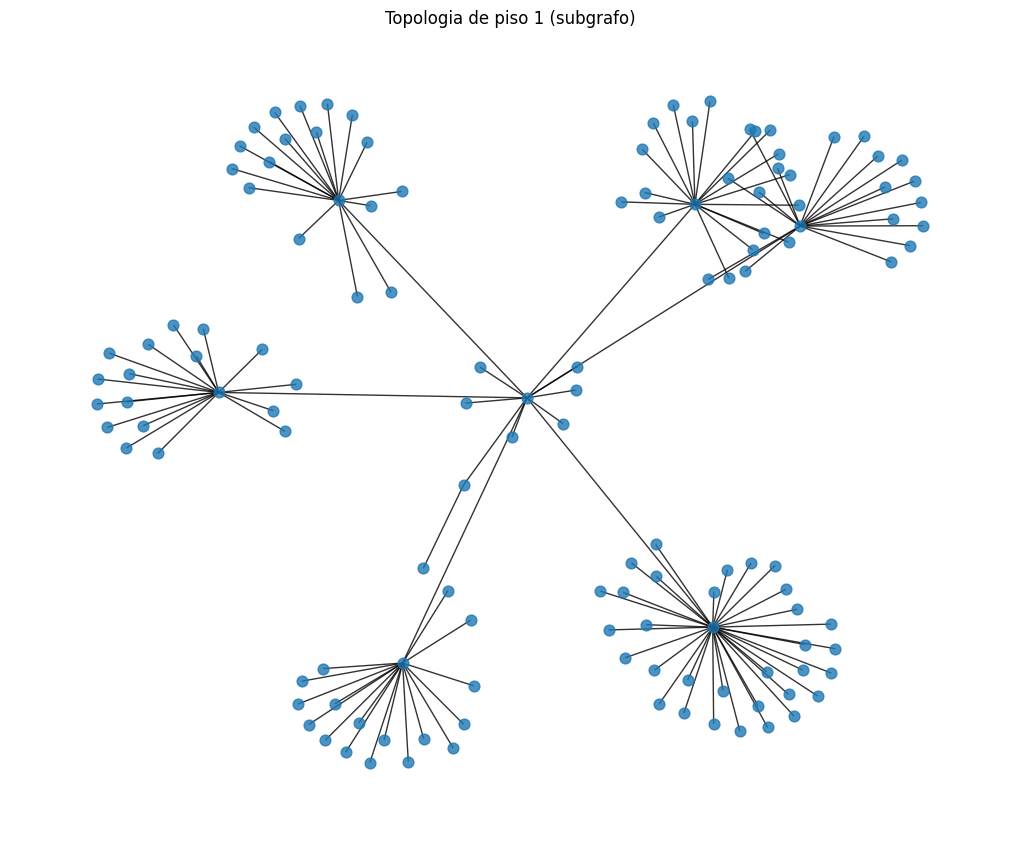

In [7]:
nodes_floor1 = [n for n, d in G.nodes(data=True) if d.get("floor") == 1]
nodes_core = ["server_central", "core_switch", "floor1_switch"]
sub_nodes = set(nodes_floor1 + nodes_core)
H = G.subgraph(sub_nodes).copy()

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42, k=0.2)
nx.draw(H, pos, node_size=60, with_labels=False, alpha=0.8)
plt.title("Topologia de piso 1 (subgrafo)")
plt.show()

## Tablas comparativas

Se comparan escenarios por alcanzabilidad y longitud de ruta promedio.

In [8]:
summary = (
    df_results.groupby("scenario")
    .agg(reachable_rate=("reachable", "mean"),
         avg_path_length=("path_length", "mean"),
         avg_visited=("visited", "mean"))
    .reset_index()
)
summary

,scenario,reachable_rate,avg_path_length,avg_visited
0,alta_seguridad,0.75,3.00,13.75
1,congestion,1.00,3.25,73.75
2,normal,1.00,3.25,73.75


## Comparacion grafica

Se muestra un grafico de barras con el porcentaje de origenes alcanzables por escenario.

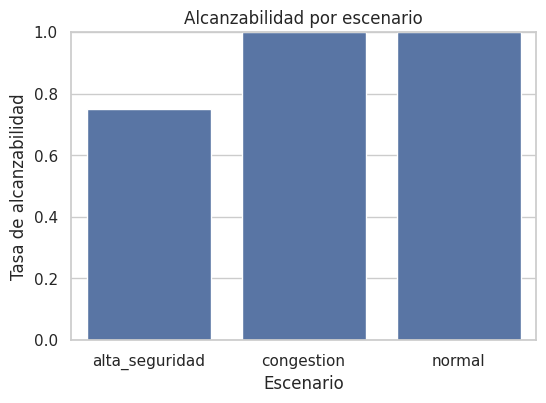

In [9]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x="scenario", y="reachable_rate")
plt.ylim(0, 1)
plt.title("Alcanzabilidad por escenario")
plt.ylabel("Tasa de alcanzabilidad")
plt.xlabel("Escenario")
plt.show()

## Conclusiones

El modelo muestra que la conectividad hacia el servidor central depende de las restricciones aplicadas sobre las aristas. En escenarios de alta seguridad, algunos origenes pueden perder alcanzabilidad por enlaces con seguridad insuficiente, mientras que en congestiona se mantiene la alcanzabilidad pero con posibles rutas mas largas. BFS permite verificar alcanzabilidad y estimar el numero de saltos con complejidad lineal sobre el tamano del grafo.

## Trabajo futuro

Se propone incorporar politicas de acceso dirigidas (grafo dirigido) y niveles de prioridad por tipo de dispositivo. Tambien se puede calibrar el modelo con datos reales de trafico del CENTIC y evaluar escenarios de falla en switches o enlaces criticos para estudiar resiliencia.